#Algoritmo A*, Heurísticas y Teoría de Juegos

 Estudiante: Kelly Jhoana Mosquera urbano

 Universidad:Universidad del Pacífico

  Materia:Inteligencia Artificial
    
Fecha de entrega: 16 de marzo de 2026


## INTRODUCCION
La inteligencia artificial es un área de la informática que se enfoca en el desarrollo de sistemas capaces de realizar tareas que normalmente requieren inteligencia humana, como la toma de decisiones, el aprendizaje y la resolución de problemas.

Según Russell y Norvig (2010), la inteligencia artificial busca desarrollar agentes capaces de percibir su entorno y tomar acciones que maximicen la probabilidad de alcanzar sus objetivos.

En este trabajo se presentan tres conceptos fundamentales dentro del campo de la inteligencia artificial: el algoritmo A*, las heurísticas y la teoría de juegos. Estos conceptos son ampliamente utilizados para resolver problemas de búsqueda, optimización y toma de decisiones estratégicas.


ALGORITMO A*

##Qué es el algoritmo A*

El algoritmo A* es un algoritmo de búsqueda informada utilizado para encontrar el camino más corto entre un nodo inicial y un nodo objetivo dentro de un grafo.

De acuerdo con Russell y Norvig, los algoritmos de búsqueda informada utilizan conocimiento adicional sobre el problema para guiar el proceso de búsqueda de manera más eficiente.

El algoritmo A* combina el costo real del camino recorrido con una estimación del costo restante hasta el objetivo, lo que permite encontrar soluciones óptimas en muchos tipos de problemas.

Este algoritmo es ampliamente utilizado en inteligencia artificial debido a su eficiencia y su capacidad para encontrar caminos óptimos.

##Para qué sirve

El algoritmo A* tiene múltiples aplicaciones en diferentes áreas de la tecnología, entre ellas:

Sistemas de navegación GPS
Videojuegos para el movimiento de personajes
Robótica para la planificación de trayectorias
Sistemas de planificación automática
Problemas de búsqueda en inteligencia artificial
Gracias a su capacidad para encontrar rutas eficientes, el algoritmo A* es uno de los métodos de búsqueda más utilizados en sistemas computacionales.

##Cómo funciona
El algoritmo A* utiliza una función de evaluación que permite estimar el costo total de un camino posible. Esta función se expresa mediante la fórmula:

La función de evaluación f(n) = g(n)+h(n)
donde:

g(n) representa el costo real desde el nodo inicial hasta el nodo actual.

h(n) representa una estimación del costo desde el nodo actual hasta el objetivo.

f(n) representa el costo total estimado del camino.

El algoritmo analiza los nodos vecinos y selecciona siempre el nodo con el menor valor de f(n). Este proceso se repite hasta que se alcanza el nodo objetivo.

Observacion

Para comprender mejor el funcionamiento del algoritmo A*, se representa gráficamente el grafo utilizado en el problema. Cada nodo representa un estado y cada arista tiene un peso que indica el costo de desplazamiento entre nodos.

Nodo visitado: X
Nodo visitado: Z
Nodo visitado: M
Nodo visitado: I

Ruta encontrada: ['X', 'Z', 'M', 'I']
Costo total: 5


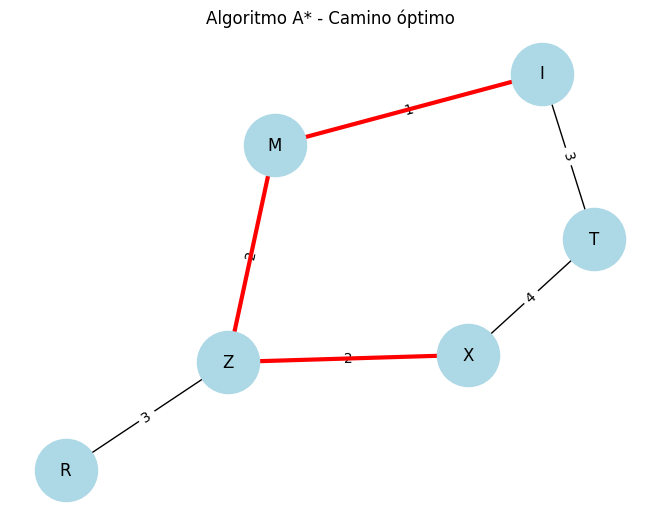

In [1]:
import heapq  # Importa heapq para usar colas de prioridad
import networkx as nx  # Librería para trabajar con grafos
import matplotlib.pyplot as plt  # Librería para visualizar el grafo


# Función para reconstruir el camino desde el objetivo hasta el inicio
def reconstruir_camino(camino, inicio, objetivo):

    ruta = []  # Lista donde se guardará la ruta
    nodo = objetivo  # Empieza desde el nodo objetivo

    while nodo != inicio:  # Retrocede hasta llegar al nodo inicial
        ruta.append(nodo)  # Agrega el nodo a la ruta
        nodo = camino[nodo]  # Se mueve al nodo anterior

    ruta.append(inicio)  # Agrega el nodo inicial
    ruta.reverse()  # Invierte la lista para mostrar la ruta correcta

    return ruta  # Devuelve la ruta completa


# Algoritmo A*
def a_estrella(inicio, objetivo, grafo, heuristica):

    abiertos = []  # Lista de nodos por explorar
    heapq.heappush(abiertos, (heuristica[inicio], inicio))  # Inserta nodo inicial

    camino = {}  # Guarda el nodo anterior de cada nodo
    costo = {inicio: 0}  # Guarda el costo desde el inicio

    while abiertos:  # Mientras haya nodos por explorar

        prioridad, actual = heapq.heappop(abiertos)  # Extrae el nodo con menor prioridad

        print("Nodo visitado:", actual)  # Muestra nodo visitado

        if actual == objetivo:  # Si llega al objetivo

            ruta = reconstruir_camino(camino, inicio, objetivo)  # Reconstruye la ruta
            return ruta, costo[objetivo]  # Devuelve ruta y costo

        for vecino in grafo[actual]:  # Recorre vecinos

            nuevo_costo = costo[actual] + grafo[actual][vecino]  # Calcula g(n)

            if vecino not in costo or nuevo_costo < costo[vecino]:

                costo[vecino] = nuevo_costo  # Actualiza costo

                prioridad = nuevo_costo + heuristica[vecino]  # Calcula f(n)

                heapq.heappush(abiertos, (prioridad, vecino))  # Inserta vecino

                camino[vecino] = actual  # Guarda nodo anterior

    return None, float("inf")  # Si no hay solución


# Grafo usado en el problema
grafo = {
    'X': {'Z': 2, 'T': 4},
    'Z': {'R': 3, 'M': 2},
    'T': {'I': 3},
    'R': {},
    'M': {'I': 1},
    'I': {}
}


# Heurística estimada al objetivo
heuristica = {
    'X': 7,
    'Z': 4,
    'T': 3,
    'R': 2,
    'M': 1,
    'I': 0
}


# Ejecutar A*
ruta, costo_total = a_estrella('X', 'I', grafo, heuristica)

print("\nRuta encontrada:", ruta)
print("Costo total:", costo_total)


#  VISUALIZACIÓN DEL GRAFO

G = nx.Graph()  # Crear grafo para visualización

# Lista de aristas
edges = [
    ('X','Z',2),
    ('X','T',4),
    ('Z','R',3),
    ('Z','M',2),
    ('M','I',1),
    ('T','I',3)
]

# Agregar aristas al grafo
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# Crear aristas del camino óptimo
edges_camino = list(zip(ruta, ruta[1:]))

# Posición de nodos
pos = nx.spring_layout(G)

# Dibujar grafo
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightblue',
    node_size=2000
)

# Dibujar pesos
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)

# Resaltar camino óptimo
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges_camino,
    edge_color='red',
    width=3
)

plt.title("Algoritmo A* - Camino óptimo")
plt.show()

###Conclusione

Durante el desarrollo de este trabajo se analizó el funcionamiento del algoritmo A*, uno de los algoritmos de búsqueda informada más utilizados en el campo de la inteligencia artificial. Este algoritmo permite encontrar el camino óptimo entre un nodo inicial y un nodo objetivo utilizando una función de evaluación que combina el costo real del camino recorrido y una estimación heurística del costo restante.

A través de las diferentes implementaciones realizadas en Python se pudo observar cómo el algoritmo explora los nodos del grafo de forma eficiente, priorizando aquellos que tienen menor costo estimado. Además, mediante la visualización del grafo se logró comprender de manera más clara la estructura del problema y el recorrido que realiza el algoritmo para encontrar la mejor solución

#HEURISTICA


##Qué es una heurística
Una heurística es una función que permite estimar el costo o la distancia desde un nodo actual hasta el objetivo dentro de un problema de búsqueda.

Según Russell y Norvig, las heurísticas permiten que los algoritmos utilicen conocimiento del problema para guiar la búsqueda de manera más eficiente, reduciendo el número de nodos que deben explorarse.

Las heurísticas no siempre garantizan la solución perfecta, pero ayudan a encontrar soluciones aceptables en un menor tiempo.

##Para qué sirve
Las heurísticas se utilizan para mejorar el rendimiento de los algoritmos de búsqueda. Algunas de sus principales ventajas son:

Reducir el espacio de búsqueda
Disminuir el tiempo de cálculo
Guiar el algoritmo hacia soluciones más prometedoras
Mejorar la eficiencia de los algoritmos
En el algoritmo A*, la heurística permite estimar qué nodos tienen mayor probabilidad de conducir al objetivo.

##Cómo funciona
La heurística funciona proporcionando una estimación del costo restante para llegar al objetivo. Esta estimación se utiliza para priorizar los nodos que parecen más cercanos a la solución.

Cuando el algoritmo analiza diferentes caminos posibles, utiliza la heurística para elegir primero aquellos caminos que tienen menor costo estimado.

De esta manera, el algoritmo puede encontrar soluciones óptimas explorando menos nodos.

###Ejemplos de heurística

#### Distancia Manhattan
La distancia Manhattan es una heurística utilizada en problemas donde el movimiento está limitado a direcciones horizontales y verticales, como ocurre en mapas de cuadrícula. Esta distancia se calcula sumando las diferencias absolutas entre las coordenadas de dos puntos.

#### Distancia Euclidiana
La distancia Euclidiana representa la distancia en línea recta entre dos puntos dentro de un plano. Este tipo de heurística se utiliza cuando el movimiento puede realizarse en cualquier direcció

In [2]:
# Definición de la función heurística Manhattan
def heuristica_manhattan(origen, destino):
    """
    Calcula la distancia Manhattan entre dos puntos en un plano.
    Parámetros:
        origen (tuple): coordenadas (x, y) del punto inicial
        destino (tuple): coordenadas (x, y) del punto objetivo
    Retorna:
        int: distancia Manhattan
    """

    x1, y1 = origen  # Extrae las coordenadas x y y del punto de origen
    x2, y2 = destino  # Extrae las coordenadas x y y del punto destino

    # Calcula la distancia Manhattan sumando la diferencia absoluta
    # entre las coordenadas en el eje x y en el eje y
    return abs(x1 - x2) + abs(y1 - y2)


# Definición del punto inicial como una tupla (x, y)
punto_inicio = (2, 3)

# Definición del punto objetivo como una tupla (x, y)
punto_objetivo = (7, 8)

# Llama a la función heurística para calcular la distancia entre los dos puntos
distancia = heuristica_manhattan(punto_inicio, punto_objetivo)

# Imprime el resultado mostrando la distancia Manhattan calculada
print(f"La distancia Manhattan entre {punto_inicio} y {punto_objetivo} es: {distancia}")

La distancia Manhattan entre (2, 3) y (7, 8) es: 10


## Explicacion

La distancia Manhattan es una heurística utilizada en algoritmos de búsqueda como A*. Esta calcula la distancia entre dos puntos sumando las diferencias absolutas de sus coordenadas en los ejes X e Y. Es muy utilizada en problemas donde los movimientos se realizan en forma de cuadrícula, como mapas, videojuegos o navegación en ciudade

In [3]:
import math  # Importa el módulo math que contiene funciones matemáticas como hypot (para calcular distancias)

# Definición de la función heurística Euclidiana
def heuristica_euclidiana(origen, destino):
    """
    Calcula la distancia Euclidiana entre dos puntos en un plano.
    Parámetros:
        origen (tuple): coordenadas (x, y) del punto inicial
        destino (tuple): coordenadas (x, y) del punto objetivo
    Retorna:
        float: distancia Euclidiana
    """

    x1, y1 = origen  # Extrae las coordenadas x y y del punto de origen
    x2, y2 = destino  # Extrae las coordenadas x y y del punto destino

    # Calcula la distancia Euclidiana usando la función hypot del módulo math
    # hypot calcula directamente √((x2-x1)² + (y2-y1)²)
    return math.hypot(x2 - x1, y2 - y1)

# Definición del punto inicial usando una tupla (x, y)
punto_inicio = (1, 2)

# Definición del punto objetivo usando una tupla (x, y)
punto_objetivo = (6, 7)

# Llama a la función heuristica_euclidiana para calcular la distancia entre los dos puntos
distancia = heuristica_euclidiana(punto_inicio, punto_objetivo)

# Imprime el resultado mostrando la distancia Euclidiana con dos decimales
print(f"La distancia Euclidiana entre {punto_inicio} y {punto_objetivo} es: {distancia:.2f}")

La distancia Euclidiana entre (1, 2) y (6, 7) es: 7.07


## Explicacion
La heurística de distancia Euclidiana calcula la distancia directa entre dos puntos en un plano cartesiano utilizando el teorema de Pitágoras. Esta heurística se basa en la idea de medir la línea recta más corta entre el punto inicial y el objetivo. En algoritmos de búsqueda como A*, se utiliza para estimar el costo restante hasta el objetivo, ayudando a que la búsqueda sea más eficiente al priorizar los nodos que están más cerca del destino.

##TEORIA DE JUEGOS

## Qué es la teoría de juegos

La teoría de juegos es una rama de las matemáticas y la economía que estudia la toma de decisiones estratégicas entre diferentes jugadores o agentes. En este campo se analizan situaciones en las que el resultado de una decisión depende no solo de las acciones de un jugador, sino también de las decisiones tomadas por otros participantes.

La teoría de juegos permite modelar diferentes escenarios de competencia y cooperación entre individuos o sistemas.

## Para qué sirve

La teoría de juegos se utiliza en diversas áreas, entre ellas:

- Economía
- Negociación y toma de decisiones
- Inteligencia artificial
- Política
- Estrategias empresariales

Mediante el análisis de estrategias y resultados posibles, la teoría de juegos permite comprender cómo interactúan los diferentes agentes en un sistema.

## Cómo funciona

En la teoría de juegos se consideran tres elementos principales:

1. Jugadores: son los participantes que toman decisiones dentro del juego.

2. Estrategias: son las posibles acciones que cada jugador puede elegir.

3. Resultados o recompensas: son las consecuencias de las decisiones tomadas por los jugadores.

Cada jugador intenta elegir la estrategia que le permita obtener el mejor resultado posible teniendo en cuenta las decisiones de los demás jugadores.


In [6]:
# 1 Ejemplo simple de teoría de juegos: Dilema del prisionero

import random  # Importa el módulo random para poder generar elecciones aleatorias

# Definición de la función que simula el dilema del prisionero
def dilema_prisionero():
    """
    Simulación del dilema del prisionero.
    Dos jugadores eligen entre 'C' (cooperar) o 'T' (traicionar).
    Se muestran las elecciones y el resultado.
    """

    # Lista que contiene las estrategias posibles para los jugadores
    opciones = ["C", "T"]

    # Cada jugador elige una estrategia al azar usando random.choice
    j1 = random.choice(opciones)  # El jugador 1 selecciona aleatoriamente cooperar o traicionar
    j2 = random.choice(opciones)  # El jugador 2 también selecciona una estrategia aleatoria

    # Imprime en pantalla la decisión tomada por el jugador 1
    print(f"Jugador 1: {j1}")

    # Imprime en pantalla la decisión tomada por el jugador 2
    print(f"Jugador 2: {j2}")

    # Diccionario que representa la matriz de pagos del dilema del prisionero
    # Cada clave es una combinación de decisiones de los jugadores
    pagos = {
        ("C", "C"): "Ambos cooperan → 3 puntos cada uno",      # Ambos cooperan
        ("C", "T"): "Jugador 2 traiciona → gana 5 puntos",     # Jugador 1 coopera y jugador 2 traiciona
        ("T", "C"): "Jugador 1 traiciona → gana 5 puntos",     # Jugador 1 traiciona y jugador 2 coopera
        ("T", "T"): "Ambos traicionan → 1 punto cada uno"      # Ambos traicionan
    }

    # Busca en el diccionario el resultado correspondiente a las elecciones de los jugadores
    print("Resultado:", pagos[(j1, j2)])

# Llama a la función para ejecutar la simulación del dilema del prisionero
dilema_prisionero()

Jugador 1: C
Jugador 2: T
Resultado: Jugador 2 traiciona → gana 5 puntos


## Explicacion

Este código simula un ejemplo sencillo de teoría de juegos, específicamente el dilema del prisionero. En la simulación, dos jugadores deben elegir entre cooperar o traicionar. Las decisiones se generan de manera aleatoria y, dependiendo de la combinación de elecciones, se determina el resultado utilizando una matriz de pagos que asigna diferentes recompensas a cada jugador.


Ronda 1
Jugador 1 eligió: R
Jugador 2 eligió: C
Resultado: Jugador 2 pierde la oportunidad → Jugador 1 gana 2 puntos

Ronda 2
Jugador 1 eligió: C
Jugador 2 eligió: C
Resultado: Ambos cazan Ciervo → 4 puntos cada uno

Ronda 3
Jugador 1 eligió: R
Jugador 2 eligió: C
Resultado: Jugador 2 pierde la oportunidad → Jugador 1 gana 2 puntos

Ronda 4
Jugador 1 eligió: R
Jugador 2 eligió: R
Resultado: Ambos cazan Conejo → 2 puntos cada uno

Ronda 5
Jugador 1 eligió: R
Jugador 2 eligió: R
Resultado: Ambos cazan Conejo → 2 puntos cada uno

Ronda 6
Jugador 1 eligió: R
Jugador 2 eligió: C
Resultado: Jugador 2 pierde la oportunidad → Jugador 1 gana 2 puntos

Ronda 7
Jugador 1 eligió: C
Jugador 2 eligió: R
Resultado: Jugador 1 pierde la oportunidad → Jugador 2 gana 2 puntos

Ronda 8
Jugador 1 eligió: C
Jugador 2 eligió: C
Resultado: Ambos cazan Ciervo → 4 puntos cada uno

Ronda 9
Jugador 1 eligió: C
Jugador 2 eligió: R
Resultado: Jugador 1 pierde la oportunidad → Jugador 2 gana 2 puntos

Ronda 10
Juga

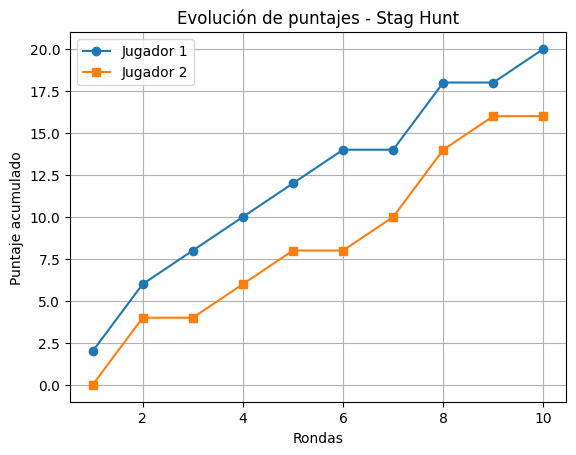

In [10]:
import random  # Importa el módulo random para generar elecciones aleatorias
import matplotlib.pyplot as plt  # Importa matplotlib para crear gráficos

# Definición de la función que simula el juego de coordinación
def juego_caza(rondas=10):
    """
    Simulación del juego de coordinación (Stag Hunt) en varias rondas.
    Dos jugadores eligen entre cazar Ciervo (C) o Conejo (R).
    Se acumulan los puntos y se grafica la evolución.
    """

    opciones = ["C", "R"]  # Lista de estrategias posibles: C = Ciervo, R = Conejo

    puntaje_j1 = 0  # Variable que almacena el puntaje total del Jugador 1
    puntaje_j2 = 0  # Variable que almacena el puntaje total del Jugador 2

    historial_j1 = []  # Lista para guardar el puntaje acumulado del Jugador 1 en cada ronda
    historial_j2 = []  # Lista para guardar el puntaje acumulado del Jugador 2 en cada ronda

    # Bucle que repite el juego durante el número de rondas indicado
    for ronda in range(1, rondas + 1):

        # Cada jugador selecciona una opción al azar
        j1 = random.choice(opciones)  # Jugador 1 elige entre C o R
        j2 = random.choice(opciones)  # Jugador 2 elige entre C o R

        # Mostrar información de la ronda actual
        print(f"\nRonda {ronda}")
        print(f"Jugador 1 eligió: {j1}")
        print(f"Jugador 2 eligió: {j2}")

        # Evaluación de las decisiones según la matriz de pagos
        if j1 == "C" and j2 == "C":
            # Si ambos cazan ciervo obtienen la mayor recompensa
            print("Resultado: Ambos cazan Ciervo → 4 puntos cada uno")
            puntaje_j1 += 4  # Se suman 4 puntos al Jugador 1
            puntaje_j2 += 4  # Se suman 4 puntos al Jugador 2

        elif j1 == "C" and j2 == "R":
            # Si el Jugador 1 intenta cazar ciervo pero el Jugador 2 elige conejo
            print("Resultado: Jugador 1 pierde la oportunidad → Jugador 2 gana 2 puntos")
            puntaje_j2 += 2  # Jugador 2 recibe 2 puntos

        elif j1 == "R" and j2 == "C":
            # Si el Jugador 2 intenta cazar ciervo pero el Jugador 1 elige conejo
            print("Resultado: Jugador 2 pierde la oportunidad → Jugador 1 gana 2 puntos")
            puntaje_j1 += 2  # Jugador 1 recibe 2 puntos

        else:
            # Si ambos cazan conejo reciben una recompensa menor pero segura
            print("Resultado: Ambos cazan Conejo → 2 puntos cada uno")
            puntaje_j1 += 2  # Se suman 2 puntos al Jugador 1
            puntaje_j2 += 2  # Se suman 2 puntos al Jugador 2

        # Guardar los puntajes acumulados después de cada ronda
        historial_j1.append(puntaje_j1)  # Guarda el puntaje del Jugador 1
        historial_j2.append(puntaje_j2)  # Guarda el puntaje del Jugador 2

    # Mostrar los resultados finales después de todas las rondas
    print("\n--- Resultados finales ---")
    print(f"Puntaje Jugador 1: {puntaje_j1}")
    print(f"Puntaje Jugador 2: {puntaje_j2}")

    # Crear un gráfico con la evolución de los puntajes
    plt.plot(range(1, rondas + 1), historial_j1, marker='o', label="Jugador 1")
    # Grafica el puntaje acumulado del Jugador 1 en cada ronda

    plt.plot(range(1, rondas + 1), historial_j2, marker='s', label="Jugador 2")
    # Grafica el puntaje acumulado del Jugador 2 en cada ronda

    plt.title("Evolución de puntajes - Stag Hunt")  # Título del gráfico
    plt.xlabel("Rondas")  # Etiqueta del eje X
    plt.ylabel("Puntaje acumulado")  # Etiqueta del eje Y

    plt.legend()  # Muestra la leyenda para identificar cada línea del gráfico
    plt.grid(True)  # Activa la cuadrícula del gráfico
    plt.show()  # Muestra el gráfico en pantalla

# Llamada a la función para ejecutar la simulación con 10 rondas
juego_caza(rondas=10)


## Explicacion
Este programa simula el juego de coordinación Stag Hunt durante varias rondas. En cada ronda, dos jugadores eligen de forma aleatoria entre cazar Ciervo o Conejo. Dependiendo de sus decisiones, se asignan puntos según una matriz de recompensas. El programa acumula los puntajes de cada jugador y, al final, genera un gráfico que muestra la evolución de los puntajes a lo largo de las rondas, permitiendo visualizar el desempeño de cada jugador durante la simulación

In [12]:
import random  # Importa el módulo random para generar elecciones aleatorias

# Definición de la función que simula el juego de colores
def juego_colores(rondas=5):
    """
    Juego de coordinación de colores.
    Dos jugadores eligen entre Rojo (R) o Azul (A).
    Si logran coordinarse, ambos ganan puntos.
    """

    opciones = ["R", "A"]  # Lista de opciones posibles: R = Rojo, A = Azul

    puntaje_j1, puntaje_j2 = 0, 0
    # Inicializa los puntajes de ambos jugadores en cero

    # Bucle que repite el juego el número de rondas indicado
    for ronda in range(1, rondas + 1):

        # Cada jugador elige un color de forma aleatoria
        j1 = random.choice(opciones)  # Jugador 1 elige entre R o A
        j2 = random.choice(opciones)  # Jugador 2 elige entre R o A

        # Muestra el número de la ronda actual
        print(f"\nRonda {ronda}")

        # Muestra la elección del Jugador 1
        print(f"Jugador 1 eligió: {j1}")

        # Muestra la elección del Jugador 2
        print(f"Jugador 2 eligió: {j2}")

        # Evaluar si ambos jugadores eligieron el mismo color
        if j1 == j2:

            # Si ambos eligieron el mismo color, hay coordinación
            print("Resultado: ¡Coordinación lograda! → 3 puntos cada uno")

            puntaje_j1 += 3  # Se suman 3 puntos al Jugador 1
            puntaje_j2 += 3  # Se suman 3 puntos al Jugador 2

        else:
            # Si eligieron colores diferentes no hay coordinación
            print("Resultado: No hay coordinación → 0 puntos")

    # Mostrar los puntajes finales después de todas las rondas
    print("\n--- Puntajes finales ---")

    print("Jugador 1:", puntaje_j1)  # Muestra el puntaje total del Jugador 1
    print("Jugador 2:", puntaje_j2)  # Muestra el puntaje total del Jugador 2

    # Determinar el ganador comparando los puntajes
    if puntaje_j1 > puntaje_j2:
        print("Ganador: Jugador 1")  # Jugador 1 gana si tiene más puntos

    elif puntaje_j2 > puntaje_j1:
        print("Ganador: Jugador 2")  # Jugador 2 gana si tiene más puntos

    else:
        print("Resultado: Empate")  # Si tienen el mismo puntaje hay empate


# Llamada a la función para ejecutar el juego con 5 rondas
juego_colores(rondas=5)


Ronda 1
Jugador 1 eligió: A
Jugador 2 eligió: A
Resultado: ¡Coordinación lograda! → 3 puntos cada uno

Ronda 2
Jugador 1 eligió: A
Jugador 2 eligió: A
Resultado: ¡Coordinación lograda! → 3 puntos cada uno

Ronda 3
Jugador 1 eligió: R
Jugador 2 eligió: A
Resultado: No hay coordinación → 0 puntos

Ronda 4
Jugador 1 eligió: A
Jugador 2 eligió: R
Resultado: No hay coordinación → 0 puntos

Ronda 5
Jugador 1 eligió: A
Jugador 2 eligió: R
Resultado: No hay coordinación → 0 puntos

--- Puntajes finales ---
Jugador 1: 6
Jugador 2: 6
Resultado: Empate


## Explicacion
Este programa simula un juego de coordinación, donde dos jugadores deben elegir entre dos colores: Rojo o Azul. Si ambos jugadores eligen el mismo color, logran coordinarse y obtienen puntos. Si eligen colores diferentes, no obtienen recompensa. El programa repite el juego durante varias rondas, acumula los puntajes y al final muestra quién obtuvo más puntos o si hubo empate.